In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Uploading the dataset 

In [9]:

import pandas as pd

df = pd.read_csv("../data/housing.csv")
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [13]:
df.info()
df.shape
df.describe()
df.isna().sum()  #checking for the missing values in each coln

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

All other columns (longitude, latitude, housing_median_age, total_rooms,
population, households, median_income, median_house_value,
ocean_proximity) do not contain missing values.

however Total_bedrooms does and now we shall handle it

In [14]:

 #Ensure numeric type
df['total_bedrooms'] = pd.to_numeric(
    df['total_bedrooms'], errors='coerce'
)

# Compute median once
median_bedrooms = df['total_bedrooms'].median()

# Impute missing values
df['total_bedrooms'].fillna(median_bedrooms, inplace=True)

# Verify
df.isna().sum()


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

The total_bedrooms feature was converted to a numeric format to handle invalid entries by coercing them to missing values. Missing values were then imputed using the median, which is robust to outliers. A final check confirmed that no missing values remained, making the dataset suitable for modeling.

Dealing with the non numerical column

In [15]:
df['ocean_proximity'] = df['ocean_proximity'].astype('category')
df.dtypes

longitude              float64
latitude               float64
housing_median_age     float64
total_rooms            float64
total_bedrooms         float64
population             float64
households             float64
median_income          float64
median_house_value     float64
ocean_proximity       category
dtype: object

The ocean_proximity column was converted to a categorical type to correctly represent it as a non‑numerical feature. This improves efficiency and prepares the feature for encoding before model training.

# Dealing with outliers #

In [16]:

import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) | 
            (df[numerical_cols] > (Q3 + 1.5 * IQR)))

outliers.sum()


longitude                0
latitude                 0
housing_median_age       0
total_rooms           1287
total_bedrooms        1306
population            1196
households            1220
median_income          681
median_house_value    1071
dtype: int64

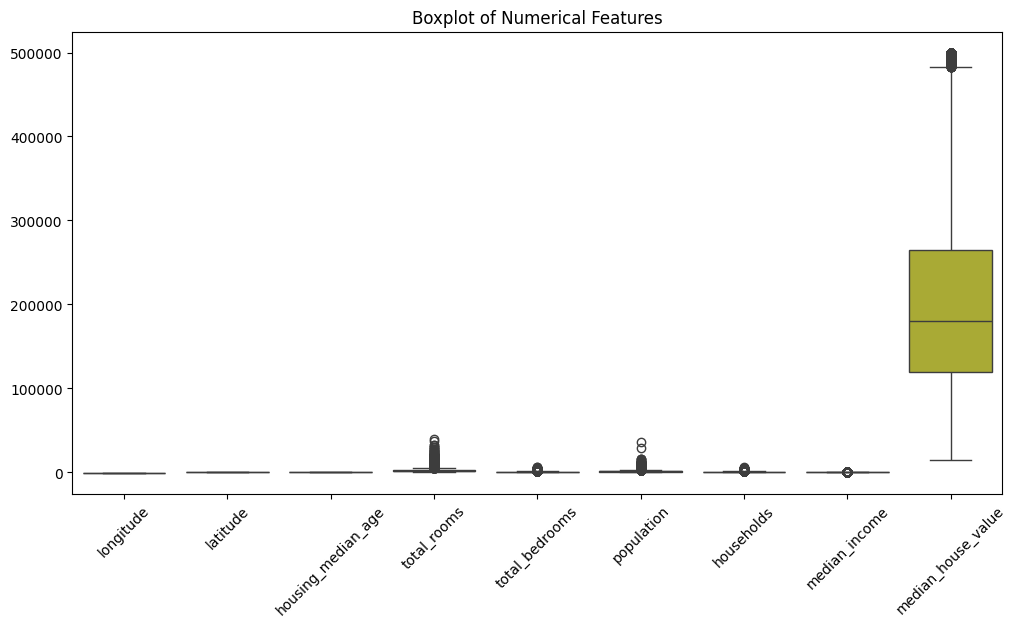

In [17]:

import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()


In [18]:

import numpy as np

cols_to_cap = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value"
]

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower, upper)


Outliers were detected using the Interquartile Range (IQR) method.
Several count‑based and economic variables exhibited a large number of outliers, which is expected given the aggregated nature of housing and population data.
These extreme values represent valid observations rather than errors.
Therefore, outliers were treated using capping (winsorization) instead of removal to reduce their influence while preserving the full dataset.

Confirmation 

In [19]:

import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_after = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) | 
                  (df[numerical_cols] > (Q3 + 1.5 * IQR)))

outliers_after.sum()


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

# Summary statistics #

In [21]:
df[numerical_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2441.692472,501.182086,1336.959012,469.020107,3.801010,205981.224976
std,2.003532,2.135952,12.585558,1397.790038,284.133641,765.550830,265.507540,1.657658,113217.350152
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,5698.375000,1162.625000,3132.000000,1092.500000,8.013025,482412.500000


 # boxplots

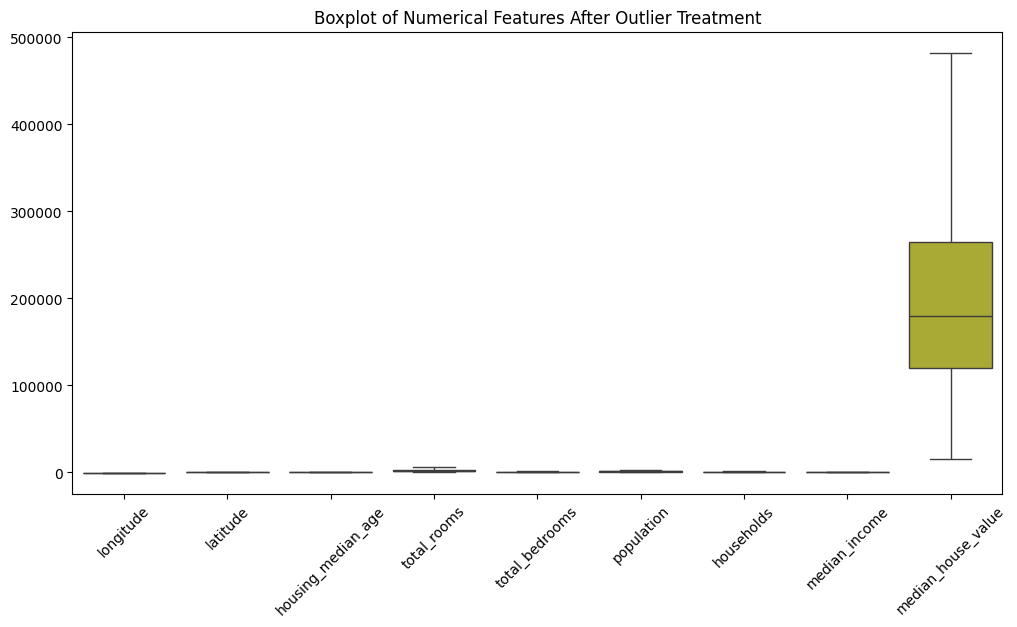

In [20]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features After Outlier Treatment")
plt.show()


After treating outliers using the IQR‑based capping method, the dataset was re‑evaluated to confirm the effectiveness of the treatment.
The IQR outlier detection was re‑applied, showing a significant reduction in extreme values.
Summary statistics and boxplots further confirmed that the influence of extreme observations was reduced while preserving the overall data distribution.

# Performing feature scaling and explain why scaling is critical for SVM and Lasso

In [22]:
#Separate features and target
from sklearn.model_selection import train_test_split

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

#Encoding the categorical feature
X = pd.get_dummies(X, columns=["ocean_proximity"], drop_first=True)

#Train–test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Apply feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Feature scaling was performed using StandardScaler to standardize numerical features to zero mean and unit variance.
Scaling is critical for Support Vector Machines because SVM relies on distance calculations, and unscaled features can dominate the decision boundary.
It is also essential for Lasso regression, as L1 regularization penalizes coefficients based on their magnitude; without scaling, features with larger numeric ranges would be penalized more heavily, leading to biased feature selection.
Therefore, feature scaling ensures fair contribution of all features and improves model performance and stability.

# Engineer at least three (3) new features, explaining Why each new feature may improve model performance

In [23]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]

df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

df["population_per_household"] = df["population"] / df["households"]

Verifying the  new features were created

In [24]:

df[[
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household"
]].describe()


,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000
mean,5.395396,0.213592,3.000738
std,2.404376,0.063380,5.200718
min,0.846154,0.076338,0.692308
25%,4.487007,0.177594,2.451816
50%,5.215904,0.204027,2.849303
75%,5.961572,0.237378,3.248158
max,141.909091,2.824675,522.000000


Three features were engineered to improve model performance. 

	Rooms per household was created to represent housing space availability, capturing living conditions more effectively than raw room counts. 

	Bedrooms per room was engineered to reflect housing layout efficiency and structural characteristics.

	Population per household was introduced to measure household crowding, which is closely related to socio economic conditions and housing prices.

These engineered features provide more informative representations of the data and help machine learning models learn meaningful relationships.


# Performing  feature selection by dropping irrelevant or redundant features 

In [25]:

features_to_drop = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households"
]

df = df.drop(columns=features_to_drop)


Feature selection was performed after feature engineering to remove redundant and less informative variables.
Features such as 

	total rooms

	total bedrooms

	population

	households 

These were dropped because they represent block level aggregates and are strongly correlated with one another.
These variables were replaced by ratio based engineered features such as rooms per household, bedrooms per room, and population per household, which provide normalized and more meaningful representations of housing density, layout efficiency, and crowding.
This reduced multicollinearity, simplified the feature space, and improved model interpretability and performance.


# Confirmation for the dropped features

In [31]:

for col in ["total_rooms", "total_bedrooms", "population", "households"]:
    print(col, "exists" if col in df.columns else "dropped")


total_rooms dropped
total_bedrooms dropped
population dropped
households dropped


 # Split the dataset into training and test sets and Explain the choice of split ratio 

In [32]:
#Separating the  features and target
from sklearn.model_selection import train_test_split

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

#Performing  the train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



The dataset was split into training and test sets using an 80:20 ratio. 
The training set was used to fit the model, while the test set was reserved 
for evaluating performance on unseen data.

This split provides a good balance between having sufficient data for learning 
and obtaining a reliable estimate of generalization performance. 

A fixed random state was used to ensure reproducibility of results.
